In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import xgboost, catboost, lightgbm,shap, optuna
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv(r'../data/wnba_players_data.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,Season,Player,G,MP,GS,FG,FGA,FG%,3P,3PA,...,USG%,ORtg,DRtg,OWS,DWS,WS,WS/40,PLUS_MINUS,award_share,is_mvp
0,1997,Anita Maxwell,9,63,0,8,25,0.320,0,0,...,25.6,72.0,89.0,-0.2,0.1,-0.1,-0.036,-5,0.0,0
1,1997,Tammi Reiss,28,831,26,72,231,0.312,30,101,...,17.0,87.0,105.0,0.2,-0.7,-0.5,-0.024,-288,0.0,0
2,1997,Catarina Pollini,13,94,0,8,22,0.364,0,0,...,17.6,77.0,92.0,-0.1,0.1,0.0,0.005,19,0.0,0
3,1997,Bridget Pettis,28,842,28,107,320,0.334,41,134,...,24.0,94.0,88.0,1.5,1.7,3.2,0.151,91,0.0,0
4,1997,Kim Perrot,28,692,24,59,162,0.364,28,99,...,16.5,87.0,87.0,0.2,1.5,1.7,0.098,155,0.0,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season       4691 non-null   int64  
 1   Player       4691 non-null   str    
 2   G            4691 non-null   int64  
 3   MP           4691 non-null   int64  
 4   GS           4691 non-null   int64  
 5   FG           4691 non-null   int64  
 6   FGA          4691 non-null   int64  
 7   FG%          4691 non-null   float64
 8   3P           4691 non-null   int64  
 9   3PA          4691 non-null   int64  
 10  3P%          4691 non-null   float64
 11  2P           4691 non-null   int64  
 12  2PA          4691 non-null   int64  
 13  2P%          4691 non-null   float64
 14  FT           4691 non-null   int64  
 15  FTA          4691 non-null   int64  
 16  FT%          4691 non-null   float64
 17  ORB          4691 non-null   int64  
 18  TRB          4691 non-null   int64  
 19  AST          4691

In [5]:
data.isna().sum()

Season         0
Player         0
G              0
MP             0
GS             0
FG             0
FGA            0
FG%            0
3P             0
3PA            0
3P%            0
2P             0
2PA            0
2P%            0
FT             0
FTA            0
FT%            0
ORB            0
TRB            0
AST            0
STL            0
BLK            0
TOV            0
PF             0
PTS            0
PER            0
TS%            0
eFG%           0
3PAr           0
FTr            0
ORB%           0
TRB%           0
AST%           0
STL%           0
BLK%           0
TOV%           0
USG%           0
ORtg           0
DRtg           0
OWS            0
DWS            0
WS             0
WS/40          0
PLUS_MINUS     0
award_share    0
is_mvp         0
dtype: int64

In [6]:
data.columns

Index(['Season', 'Player', 'G', 'MP', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER', 'TS%', 'eFG%', '3PAr', 'FTr',
       'ORB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'ORtg', 'DRtg',
       'OWS', 'DWS', 'WS', 'WS/40', 'PLUS_MINUS', 'award_share', 'is_mvp'],
      dtype='str')

In [7]:
df = pd.DataFrame()
# subset important features
# features that show players skill level as well as their impact on the court
df = data[['Season', 'Player', 'TS%','WS', 'PER', 'USG%','PLUS_MINUS','award_share','is_mvp']]
df['pts_per_game'] = data['PTS'] / data['G']
df['stl_per_game'] = data['STL'] / data['G']
df['ast_per_game'] = data['AST'] / data['G']
df['trb_per_game'] = data['TRB'] / data['G']
df['blk_per_game'] = data['BLK'] / data['G']

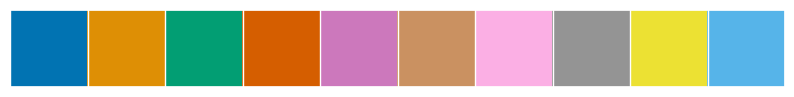

In [8]:
sns.set_style('darkgrid')
sns.set_palette('colorblind')
sns.set(font_scale=0.8)

palette = sns.color_palette('colorblind')
sns.palplot(palette)

Explarotary Data Analysis

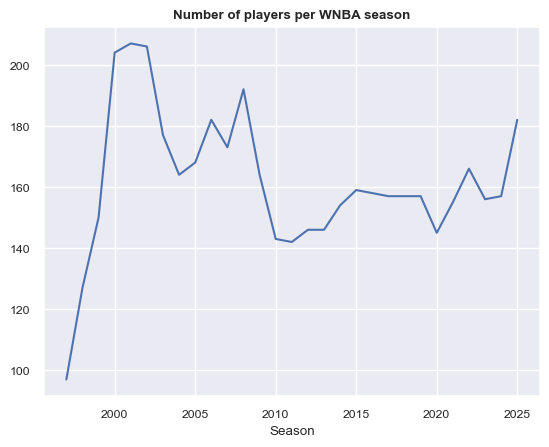

In [8]:
df['Season'].value_counts(sort=False).plot.line()
plt.title("Number of players per WNBA season", fontweight='bold')
plt.show()

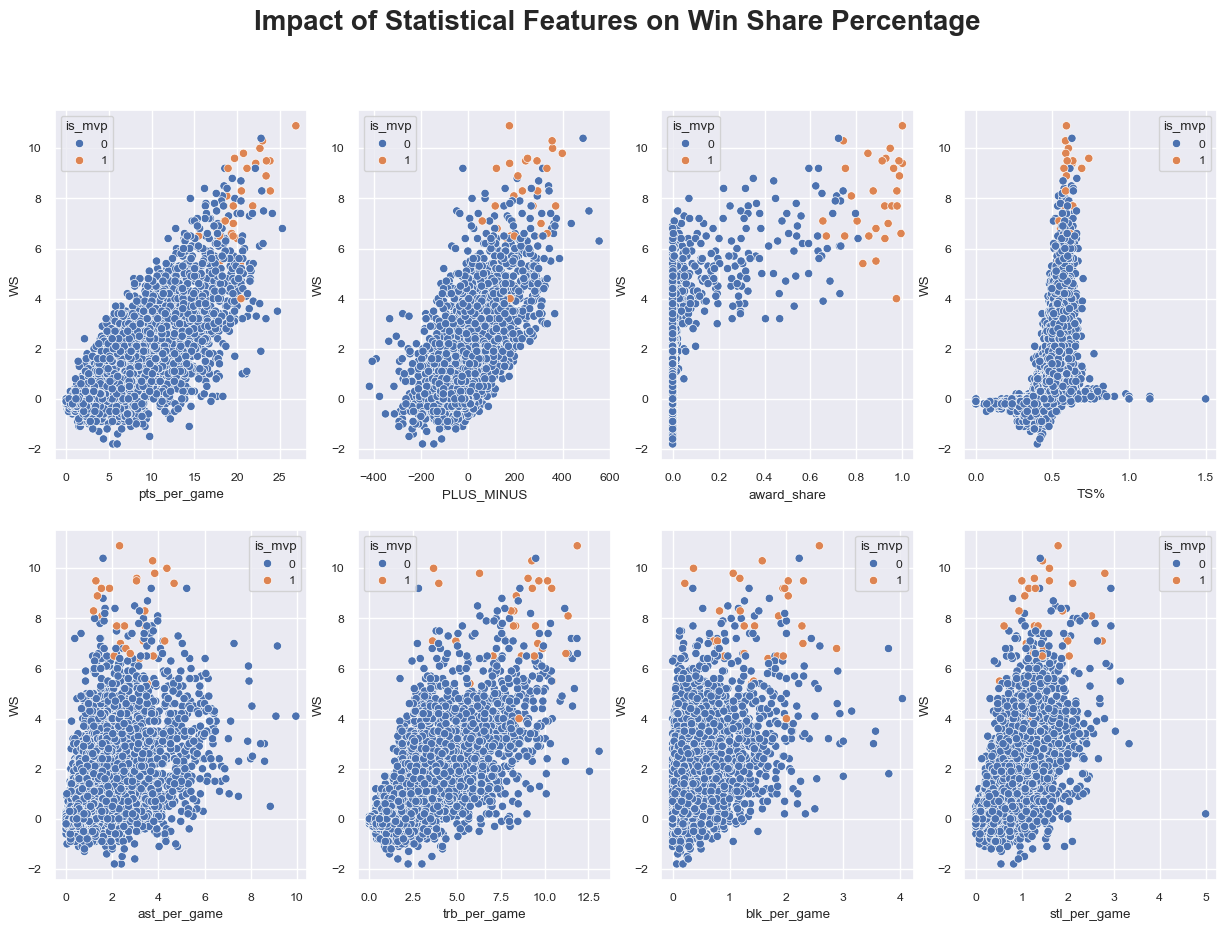

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='pts_per_game',
    y='WS',
    ax=axes[0,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='PLUS_MINUS',
    y='WS',
    ax=axes[0,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='award_share',
    ax=axes[0,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='TS%',
    y='WS',
    ax=axes[0,3]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='ast_per_game',
    ax=axes[1,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='trb_per_game',
    ax=axes[1,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='blk_per_game',
    ax=axes[1,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Impact of Statistical Features on Win Share Percentage', fontsize=20, fontweight='bold')
plt.show()

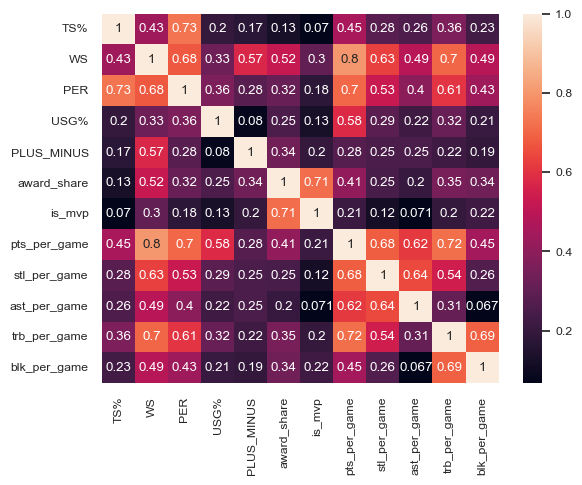

In [10]:
sns.heatmap(data=df[df.columns[2:]].corr(), annot=True)
plt.show()

Award share is highly correlated WS%, that means player who contribute to their teams total wins have a higher chance of getting MVP votes 

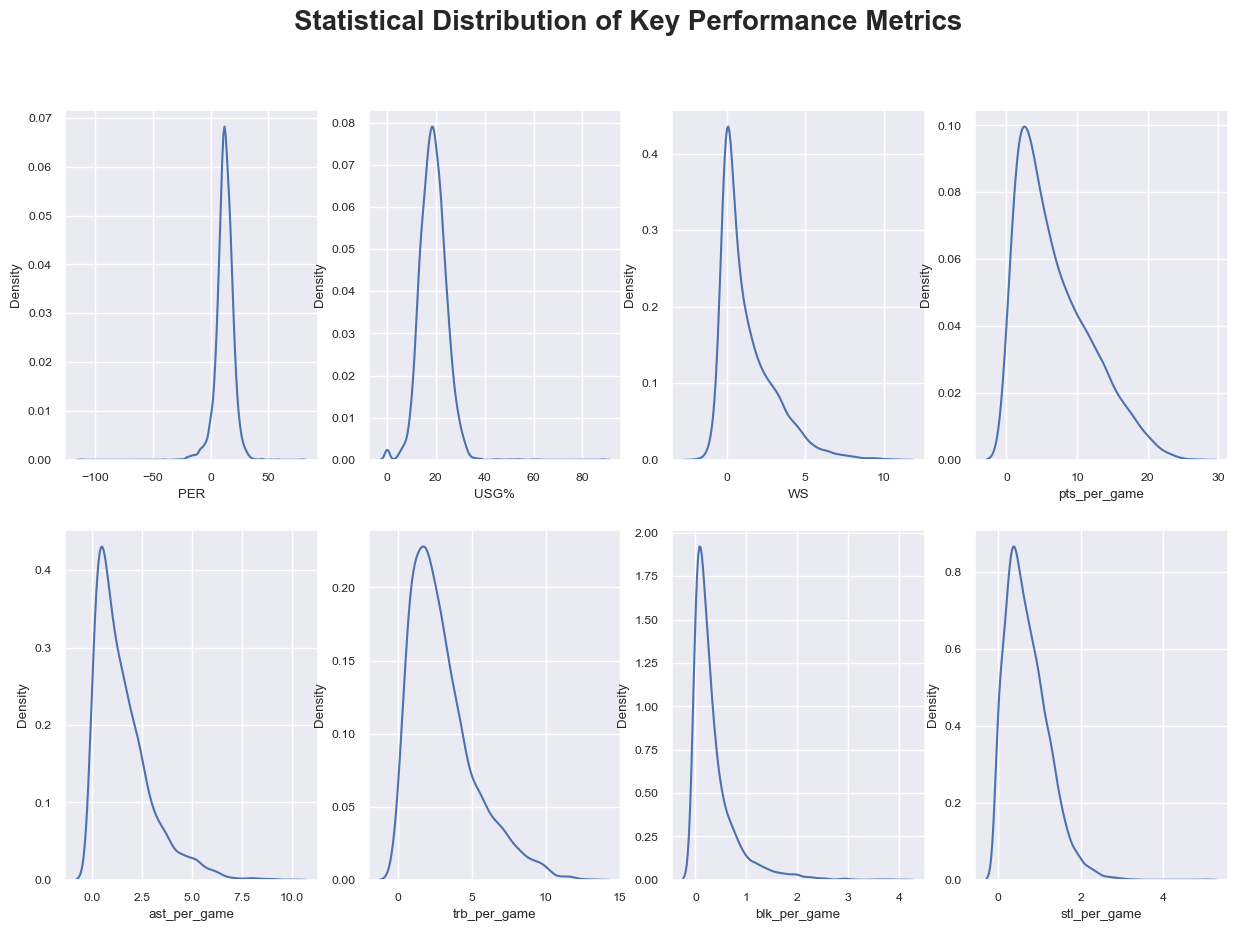

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.kdeplot(
    data=df,
    x='PER',
    ax=axes[0,0]
)
sns.kdeplot(
    data=df,
    x='USG%',
    ax=axes[0,1]
)
sns.kdeplot(
    data=df,
    x='WS',
    ax=axes[0,2]
)
sns.kdeplot(
    data=df,
    x='pts_per_game',
    ax=axes[0,3]
)
sns.kdeplot(
    data=df,
    x='ast_per_game',
    ax=axes[1,0]
)
sns.kdeplot(
    data=df,
    x='trb_per_game',
    ax=axes[1,1]
)
sns.kdeplot(
    data=df,
    x='blk_per_game',
    ax=axes[1,2]
)
sns.kdeplot(
    data=df,
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distribution of Key Performance Metrics', fontsize=20, fontweight='bold')
plt.show()

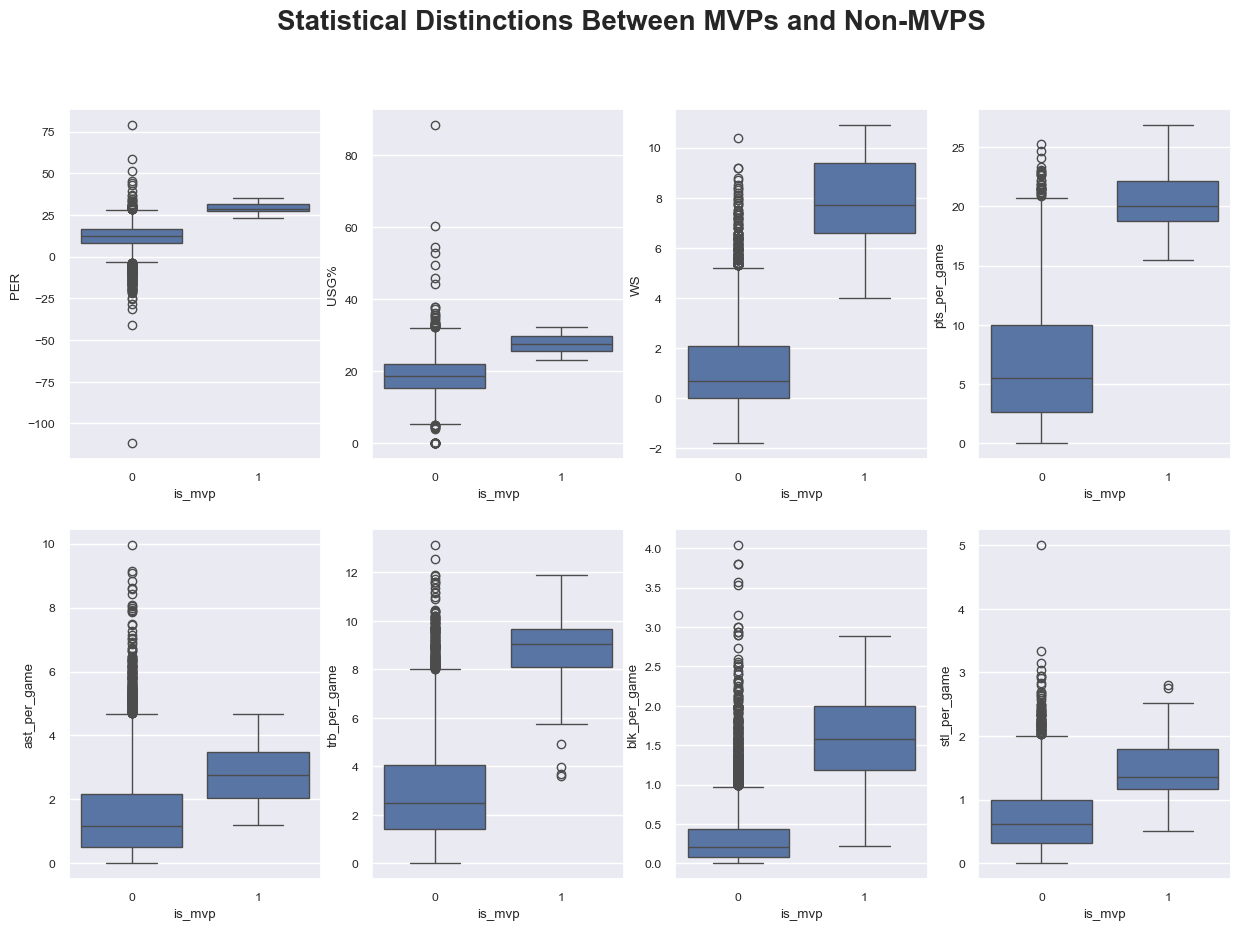

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.boxplot(
    data=df,
    x='is_mvp',
    y='PER',
    ax=axes[0,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='USG%',
    ax=axes[0,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='WS',
    ax=axes[0,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='pts_per_game',
    ax=axes[0,3]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='ast_per_game',
    ax=axes[1,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='trb_per_game',
    ax=axes[1,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='blk_per_game',
    ax=axes[1,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distinctions Between MVPs and Non-MVPS', fontsize=20, fontweight='bold')
plt.show()

Most of the non-MVP players fall behind MVPs in all statistical categories but there are also alot high-performing non-MVPs

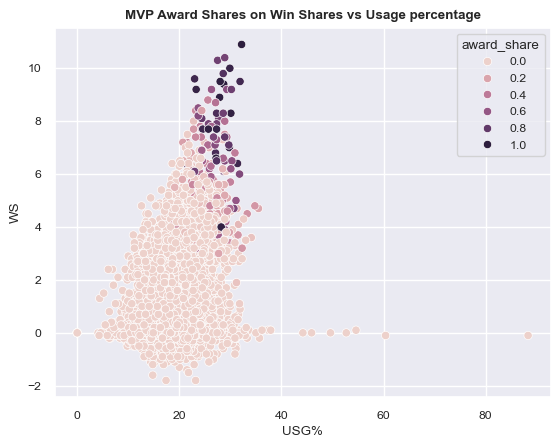

In [13]:
sns.scatterplot(data=data, x='USG%', y='WS', hue='award_share')
plt.title("MVP Award Shares on Win Shares vs Usage percentage", fontweight='bold')
plt.show()

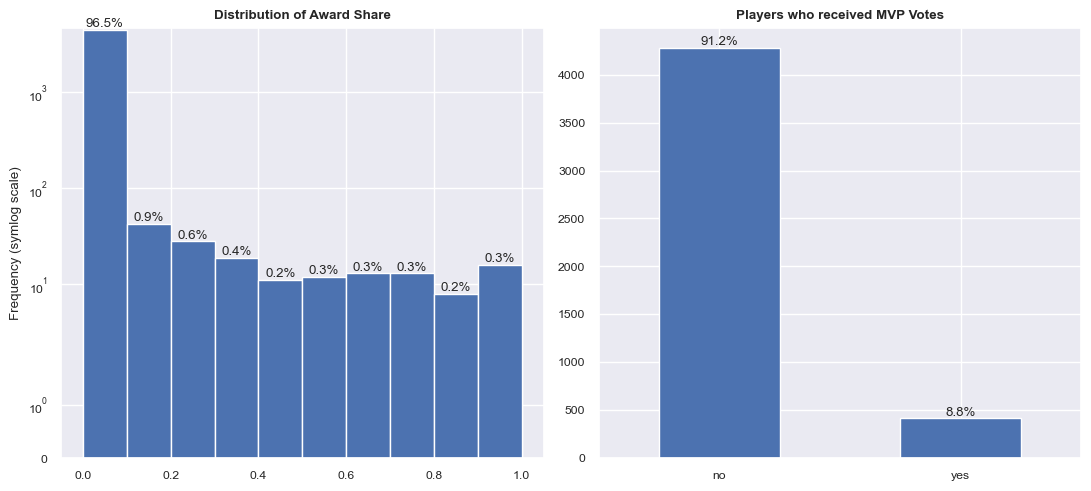

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
total = len(df)

df['award_share'].plot(kind='hist', ax=axes[0])
# Annotate the bars
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom')
axes[0].set_title("Distribution of Award Share", fontweight='bold')
axes[0].set_yscale('symlog')
axes[0].set_ylabel("Frequency (symlog scale)") 

pie_series = pd.Series(np.where(df['award_share'] > 0, 'yes', 'no'))

pie_series.value_counts().plot(kind='bar', ax=axes[1])


for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom')

axes[1].set_title('Players who received MVP Votes', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

the vast majority of the league (96.5%) receives exactly 0.0 award shares. This insight justifies abandoning standard binary classification.

In [15]:
X = df.drop(columns=['Season','Player','is_mvp', 'award_share'])

X_standardized = StandardScaler().fit_transform(X)
X_standardized.shape

(4691, 10)

In [16]:
tsne = TSNE(n_components=2, random_state=0)
tsne_X = tsne.fit_transform(X_standardized)
tsne_X

array([[-59.381123  ,  10.950104  ],
       [  0.44379595, -30.431894  ],
       [-49.65098   ,  -4.2110395 ],
       ...,
       [-37.842297  , -29.316021  ],
       [-32.333466  , -19.003181  ],
       [  3.402483  ,  27.515305  ]], shape=(4691, 2), dtype=float32)

In [17]:
tsne_df = pd.DataFrame(data=tsne_X, columns=["Dim_1", "Dim_2"])
tsne_df['is_mvp'] = df['is_mvp'].values
tsne_df['award_share'] = df['award_share'].values

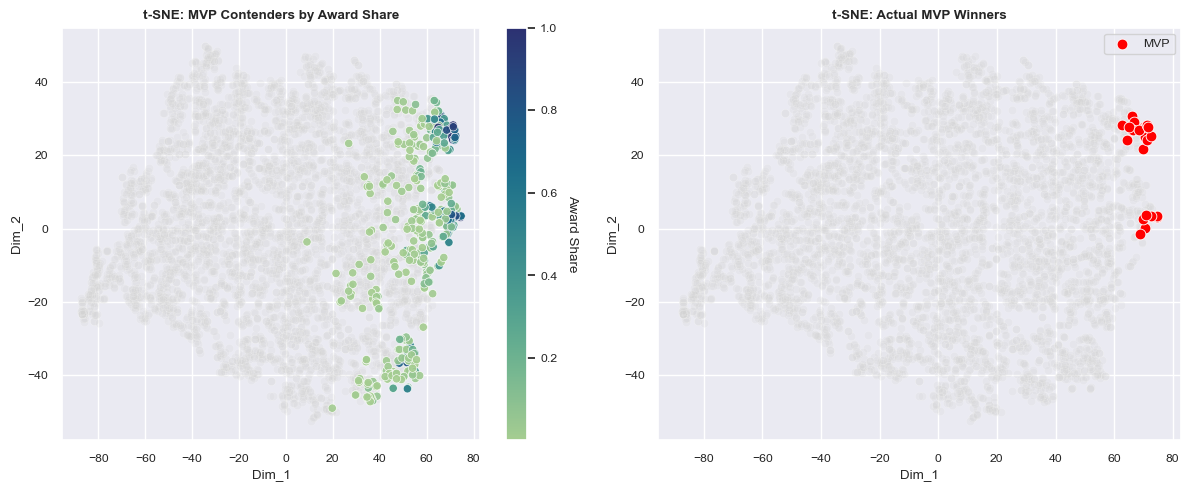

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Layer 1: The Zeros
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] == 0], 
    x='Dim_1', y='Dim_2', 
    color='lightgrey', 
    alpha=0.2, 
    ax=axes[0],
)

# Layer 2: The Contenders 
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] > 0], 
    x='Dim_1', y='Dim_2', 
    hue='award_share', 
    palette='crest', 
    alpha=0.9, 
    ax=axes[0],
    legend=False 
)

# Continuous Colorbar
min_vote = tsne_df[tsne_df['award_share'] > 0]['award_share'].min()
norm = Normalize(vmin=min_vote, vmax=1)

# a ScalarMappable object using chosen palette and normalizer
sm = plt.cm.ScalarMappable(cmap='crest', norm=norm)
sm.set_array([])

# 4. Attach the colorbar to the first subplot
cbar = fig.colorbar(sm, ax=axes[0])
cbar.set_label('Award Share', rotation=270, labelpad=15) # Add a nice label

axes[0].set_title("t-SNE: MVP Contenders by Award Share", fontweight='bold')


# Plot 2: is_mvp 
sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 0], 
    x='Dim_1', y='Dim_2', color='lightgrey', alpha=0.2, ax=axes[1]
)

sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 1], 
    x='Dim_1', y='Dim_2', color='red', alpha=1.0, s=60, ax=axes[1], label='MVP'
)
axes[1].set_title("t-SNE: Actual MVP Winners", fontweight='bold')

plt.tight_layout()
plt.show()

revealed a distinct "elite cluster." But of because some high-performing non-MVPs merge into that cluster, the visualization confirms that standard metrics alone cannot flawlessly isolate an MVP without a sophisticated gradient boosting approach.

normalize features within season
What actually determines MVP voting is how dominant a player was relative to her peers that year — not her raw numbers.

Hyperparameter tuning using optuna then Training and testing

In [9]:
season_cols = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game', 'ast_per_game',
               'trb_per_game', 'blk_per_game', 'stl_per_game'] # plus minus is a season total, not a per-game rate

for col in season_cols:
    df[f'{col}_z'] = df.groupby('Season')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

df_sorted = df.sort_values(by=['Season', 'Player']).reset_index(drop=True)

features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z','pts_per_game_z', 'ast_per_game_z',
             'trb_per_game_z', 'blk_per_game_z','stl_per_game_z']
target = 'award_share'

def walk_forward_validation(estimator,features=features,target=target ,df=df,start_test_year=1999, end_test_year=2025):
    yearly_r2 = {}
    yearly_rmse = {}
    all_model_predictions = []

    for test_year in range(start_test_year, end_test_year+1):
        
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]
        
        estimator.fit(X_train, y_train)
        
        y_pred = estimator.predict(X_test)

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Predicted_Share': y_pred
        })
    
        eval_df['Predicted_Share'] = eval_df['Predicted_Share'].clip(lower=0)
        all_model_predictions.append(eval_df)

        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)**(1/2)

        yearly_r2[test_year] = r2
        yearly_rmse[test_year] = rmse
    
    final_predictions_df = pd.concat(all_model_predictions, ignore_index=True)
    overall_r2 = sum(yearly_r2.values())/len(yearly_r2)
    overall_rmse = sum(yearly_rmse.values())/len(yearly_rmse)
    
    return {'overall_r2':overall_r2, 'overall_rmse':overall_rmse, 'final_predictions':final_predictions_df}

In [26]:
raw_features = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game',
                'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game']

z_features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z', 'pts_per_game_z',
              'ast_per_game_z', 'trb_per_game_z', 'blk_per_game_z', 'stl_per_game_z']

default_params = dict(loss_function='RMSE', random_state=0, verbose=0)  # identical params both runs

raw_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), raw_features, target, df_sorted
)
z_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), z_features, target, df_sorted
)

print("Raw R²:", raw_results['overall_r2'])
print("Season-normalized R²:", z_results['overall_r2'])

Raw R²: 0.6461307708148892
Season-normalized R²: 0.686181806998142


In [33]:
from scipy.stats import spearmanr
baseline_corr = spearmanr(df['WS'], df['award_share'])
baseline_corr

SignificanceResult(statistic=np.float64(0.4468678023544195), pvalue=np.float64(4.015317217985721e-229))

In [10]:
single_feature_results = walk_forward_validation(
    estimator=catboost.CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_state=0),
    features=['WS_z'], target=target, df=df_sorted 
)

In [11]:
predicted_mvps_rf = single_feature_results['final_predictions'].groupby('Season').head(1).reset_index(drop=True)

actual_mvps = single_feature_results['final_predictions'].sort_values(
       by=['Season','Actual_Share'], ascending=[True, False]
   ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

comparison_rf = predicted_mvps_rf[['Season','Player']].rename(
       columns={'Player':'Predicted_MVP'}
   ).merge(actual_mvps, on='Season')

print(f"Top-1 hit rate: {(comparison_rf['Predicted_MVP'] == comparison_rf['Actual_MVP']).mean():.2%}")

Top-1 hit rate: 14.81%


A p-value of 4.01e-229 proves that the strong relationship between WS and MVP voting. However, the correlation coefficient of 0.447 is only moderate. This is the exact justification needed for deploying complex tree algorithms (XGBoost, CatBoost). At 0.447, the algorithm must look at non-linear interactions across the other 7 features (like USG% and pts_per_game) to find the MVP.

In [44]:
def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'eta': trial.suggest_float('eta', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_state': 0,
    }
    results = walk_forward_validation(
        estimator=xgboost.XGBRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2010, end_test_year=2025
    )
    return results['overall_r2']

In [45]:
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=40)
print(study.best_params, study.best_value)

[I 2026-06-21 13:05:52,678] A new study created in memory with name: no-name-28582e14-41df-4749-825e-89a281732047
[I 2026-06-21 13:06:04,547] Trial 0 finished with value: 0.7268985721438249 and parameters: {'max_depth': 8, 'eta': 0.03948444967277224, 'n_estimators': 737, 'subsample': 0.6064460767309883}. Best is trial 0 with value: 0.7268985721438249.
[I 2026-06-21 13:06:14,778] Trial 1 finished with value: 0.7307421886127579 and parameters: {'max_depth': 7, 'eta': 0.026102842239189357, 'n_estimators': 772, 'subsample': 0.6625486264912088}. Best is trial 1 with value: 0.7307421886127579.
[I 2026-06-21 13:06:19,919] Trial 2 finished with value: 0.7279623926479024 and parameters: {'max_depth': 8, 'eta': 0.06745713360726653, 'n_estimators': 550, 'subsample': 0.8349041839964622}. Best is trial 1 with value: 0.7307421886127579.
[I 2026-06-21 13:06:21,897] Trial 3 finished with value: 0.7054851367573558 and parameters: {'max_depth': 3, 'eta': 0.052720286137911576, 'n_estimators': 381, 'subsa

{'max_depth': 4, 'eta': 0.012364318721607502, 'n_estimators': 509, 'subsample': 0.6646588726735754} 0.7473962799909065


In [24]:
def catb_objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 200, 800),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'random_state': 0,
        'verbose': 0,
    }
    results = walk_forward_validation(
        estimator=catboost.CatBoostRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2010, end_test_year=2025 
    )
    return results['overall_r2']

study2 = optuna.create_study(direction='maximize')
study2.optimize(catb_objective, n_trials=40)
print(study2.best_params, study2.best_value)

[I 2026-06-21 00:42:13,639] A new study created in memory with name: no-name-33bbd015-5c3a-47e3-a534-0890583a1b66
[I 2026-06-21 00:42:20,479] Trial 0 finished with value: 0.7237090627451229 and parameters: {'depth': 3, 'learning_rate': 0.061053335048500315, 'iterations': 381, 'l2_leaf_reg': 7.054891315771352}. Best is trial 0 with value: 0.7237090627451229.
[I 2026-06-21 00:42:29,395] Trial 1 finished with value: 0.7347075785112464 and parameters: {'depth': 4, 'learning_rate': 0.016060502371462435, 'iterations': 451, 'l2_leaf_reg': 7.254422711740724}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:37,191] Trial 2 finished with value: 0.7153441466313714 and parameters: {'depth': 4, 'learning_rate': 0.07218292651117546, 'iterations': 386, 'l2_leaf_reg': 4.4905648225503745}. Best is trial 1 with value: 0.7347075785112464.
[I 2026-06-21 00:42:49,434] Trial 3 finished with value: 0.7306763200900426 and parameters: {'depth': 7, 'learning_rate': 0.049229344630469435, 'ite

{'depth': 3, 'learning_rate': 0.024500159421583276, 'iterations': 277, 'l2_leaf_reg': 5.610492949525419} 0.738199112539097


In [40]:
def lightgbm_objective(trial):
    params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': trial.suggest_int('num_leaves', 63, 127),
    'learning_rate': trial.suggest_float('learning_rate', 0.01,0.05),
    'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.7),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.7),
    'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
    'random_state':0,
    'verbose':-1
    }
    results = walk_forward_validation(
        estimator=lightgbm.LGBMRegressor(**params),
        features=features,target=target, df=df_sorted,
        start_test_year=2010,end_test_year=2025 
    )
    return results['overall_r2']

study3 = optuna.create_study(direction='maximize')
study3.optimize(lightgbm_objective, n_trials=40)
print(study3.best_params, study3.best_value)

[I 2026-06-21 12:48:27,056] A new study created in memory with name: no-name-6fb9cc43-e811-4d78-a0a3-843076210113
[I 2026-06-21 12:48:29,315] Trial 0 finished with value: 0.585101062732655 and parameters: {'num_leaves': 106, 'learning_rate': 0.01020252954764032, 'feature_fraction': 0.6544281617937594, 'colsample_bytree': 0.6580896514193618, 'min_child_samples': 20}. Best is trial 0 with value: 0.585101062732655.
[I 2026-06-21 12:48:31,260] Trial 1 finished with value: 0.7222550757382111 and parameters: {'num_leaves': 107, 'learning_rate': 0.04667139352785764, 'feature_fraction': 0.6291646858711296, 'colsample_bytree': 0.6482120147980323, 'min_child_samples': 31}. Best is trial 1 with value: 0.7222550757382111.
[I 2026-06-21 12:48:32,660] Trial 2 finished with value: 0.5993362691485492 and parameters: {'num_leaves': 73, 'learning_rate': 0.015582024971508731, 'feature_fraction': 0.6906594049571348, 'colsample_bytree': 0.6247449533767624, 'min_child_samples': 50}. Best is trial 1 with val

{'num_leaves': 90, 'learning_rate': 0.03798712141324875, 'feature_fraction': 0.6223499378819357, 'colsample_bytree': 0.6130319548715177, 'min_child_samples': 21} 0.736595348957186


In [41]:
def walk_forward_validation_ranker(estimator, features=features, target=target, df=df_sorted, start_test_year=1999, end_test_year=2025):
    all_preds = []
    hits = []

    for test_year in range(start_test_year, end_test_year + 1):
        train_data = df[df['Season'] < test_year].sort_values('Season')  # must be contiguous by group
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]

        group_sizes = train_data.groupby('Season').size().values

        estimator.fit(X_train, y_train, group=group_sizes)
        y_pred = estimator.predict(X_test)   # raw ranking score — NOT an award_share estimate

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Predicted_Score': y_pred
        })
        all_preds.append(eval_df)

        predicted_top = eval_df.loc[eval_df['Predicted_Score'].idxmax(), 'Player']
        actual_top = eval_df.loc[eval_df['Actual_Share'].idxmax(), 'Player']
        hits.append(predicted_top == actual_top)

    final_predictions_df = pd.concat(all_preds, ignore_index=True)
    return {'hit_rate': sum(hits) / len(hits), 'final_predictions': final_predictions_df}

In [70]:
ranker = xgboost.XGBRanker(objective='rank:pairwise', random_state=0)
ranker_results = walk_forward_validation_ranker(
    estimator=ranker
)

print(f"Top-1 hit rate: {ranker_results['hit_rate']:.2%}")

ranker_sorted_preds = ranker_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Score'], ascending=[True, False]
)
predicted_mvps_ranker = ranker_sorted_preds.groupby('Season').head(1).reset_index(drop=True)
predicted_mvps_ranker[['Season', 'Player', 'Predicted_Score', 'Actual_Share']]

Top-1 hit rate: 51.85%


,Season,Player,Predicted_Score,Actual_Share
0,1999,Cynthia Cooper,5.283153,0.635
1,2000,Sheryl Swoopes,6.635667,0.850
2,2001,Yolanda Griffith,5.953008,0.317
3,2002,Tamika Catchings,6.632094,0.593
4,2003,Lauren Jackson,6.556503,0.752
5,2004,Lauren Jackson,6.805921,0.731
6,2005,Lauren Jackson,6.768949,0.650
7,2006,Diana Taurasi,6.432983,0.384
8,2007,Lauren Jackson,5.169903,0.985
9,2008,Candace Parker,6.024451,0.923


In [11]:
catb_bestparams = {'depth': 3, 'learning_rate': 0.024500159421583276, 'iterations': 277, 'l2_leaf_reg': 5.610492949525419}
xgb_bestparams = {'max_depth': 4, 'eta': 0.012364318721607502, 'n_estimators': 509, 'subsample': 0.6646588726735754}
lightgbm_bestparams = {'num_leaves': 90, 'learning_rate': 0.03798712141324875, 'feature_fraction': 0.6223499378819357, 'colsample_bytree': 0.6130319548715177, 'min_child_samples': 21}

catb = catboost.CatBoostRegressor(**catb_bestparams, loss_function='RMSE', random_state=0, verbose=0)
xgb = xgboost.XGBRegressor(**xgb_bestparams, random_state=0)
lgbm = lightgbm.LGBMRegressor(**lightgbm_bestparams, random_state=0, verbose=-1)

In [53]:
catb_results = walk_forward_validation(
                estimator=catb,
                features=features,
                target=target)

print(f'r2: {catb_results['overall_r2']}')
print(f'rmse: {catb_results['overall_rmse']}')

catb_sorted_preds = catb_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Share'], 
    ascending=[True, False]
)

predicted_mvps_catb = catb_sorted_preds.groupby('Season').head(1).reset_index(drop=True)

actual_mvps = catb_results['final_predictions'].sort_values(
       by=['Season','Actual_Share'], ascending=[True, False]
   ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

comparison_catb = predicted_mvps_catb[['Season','Player']].rename(
       columns={'Player':'Predicted_MVP'}
   ).merge(actual_mvps, on='Season')

print(f"Top-1 hit rate: {(comparison_catb['Predicted_MVP'] == comparison_catb['Actual_MVP']).mean():.2%}")

r2: 0.7035234778541847
rmse: 0.050253716150971725
Top-1 hit rate: 44.44%


In [ ]:
xgb_results = walk_forward_validation(
    estimator=xgb,
    features=features,
    target=target
    )

print(f'r2: {xgb_results['overall_r2']}')
print(f'rmse: {xgb_results['overall_rmse']}')

xgb_sorted_preds = xgb_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Share'], 
    ascending=[True, False]
)

predicted_mvps_xgb = xgb_sorted_preds.groupby('Season').head(1).reset_index(drop=True)
actual_mvps = xgb_results['final_predictions'].sort_values(
       by=['Season','Actual_Share'], ascending=[True, False]
   ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

comparison_xgb = predicted_mvps_xgb[['Season','Player']].rename(
       columns={'Player':'Predicted_MVP'}
   ).merge(actual_mvps, on='Season')

print(f"Top-1 hit rate: {(comparison_xgb['Predicted_MVP'] == comparison_xgb['Actual_MVP']).mean():.2%}")

Top-1 hit rate: 40.74%


In [55]:
lgbm_results = walk_forward_validation(
                estimator=lgbm,
                features=features,
                target=target)

print(f'r2: {lgbm_results['overall_r2']}')
print(f'rmse: {lgbm_results['overall_rmse']}')

lgbm_sorted_preds = lgbm_results['final_predictions'].sort_values(
    by=['Season', 'Predicted_Share'], 
    ascending=[True, False]
)

predicted_mvps_lgbm = lgbm_sorted_preds.groupby('Season').head(1).reset_index(drop=True)

actual_mvps = lgbm_results['final_predictions'].sort_values(
       by=['Season','Actual_Share'], ascending=[True, False]
   ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

comparison_lgbm = predicted_mvps_lgbm[['Season','Player']].rename(
       columns={'Player':'Predicted_MVP'}
   ).merge(actual_mvps, on='Season')

print(f"Top-1 hit rate: {(comparison_lgbm['Predicted_MVP'] == comparison_lgbm['Actual_MVP']).mean():.2%}")

r2: 0.6686103659430463
rmse: 0.05295564043887083
Top-1 hit rate: 55.56%


Text(0.5, 1.0, 'XGBoost Regressor Model')

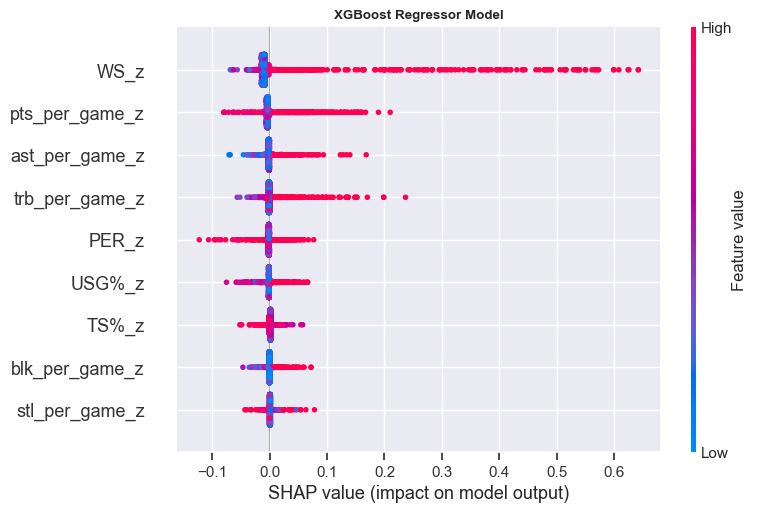

In [69]:
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer(df[features])
shap.summary_plot(xgb_shap_values, df[features], show=False)
plt.title("XGBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'CATBoost Regressor Model')

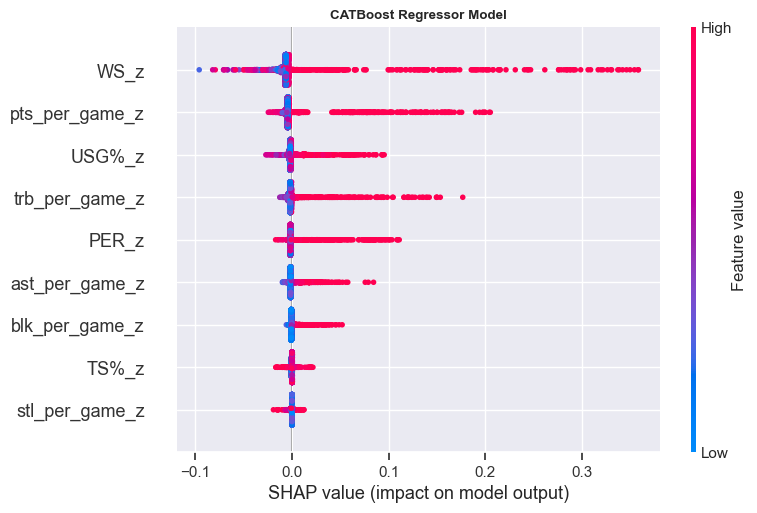

In [68]:
explainer = shap.TreeExplainer(catb)
shap_values = explainer(df[features])

shap.summary_plot(shap_values, df[features], show=False)
plt.title("CATBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'LightGBM Regressor Model')

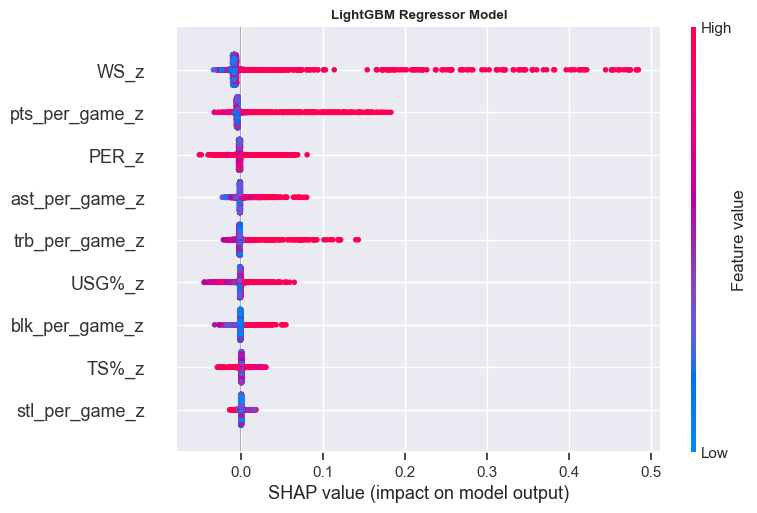

In [67]:
lightgbm_explainer = shap.TreeExplainer(lgbm)
lightgbm_shap_values = lightgbm_explainer(df[features])
shap.summary_plot(lightgbm_shap_values, df[features], show=False)
plt.title("LightGBM Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'XGBoost Ranker Model')

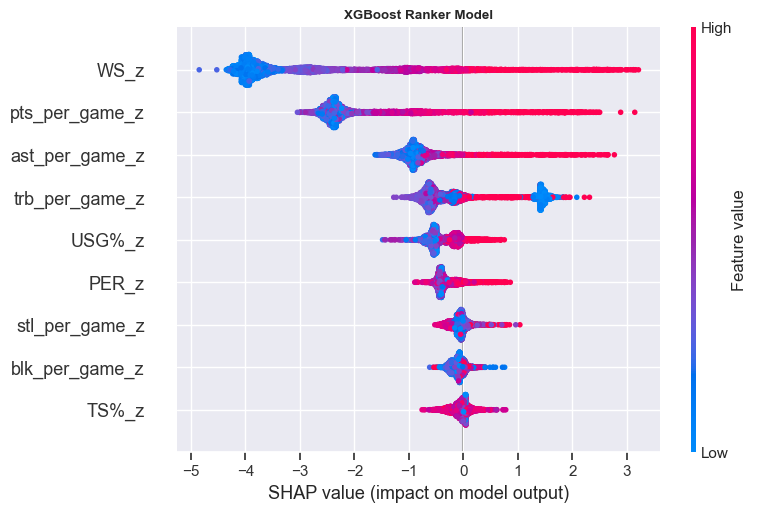

In [71]:
xgbranker_explainer = shap.TreeExplainer(ranker)
xgbranker_shap_values = xgbranker_explainer(df[features])
shap.summary_plot(xgbranker_shap_values, df[features], show=False)
plt.title("XGBoost Ranker Model", fontweight='bold')